# Cybersecurity Breach Incidents — EDA (Beginner Friendly)

### What is EDA?
**Exploratory Data Analysis (EDA)** is the very first thing any data analyst does after getting a new dataset. Instead of jumping straight into building models, we first explore the data using simple statistics, tables, and charts. This helps us understand what kind of information we have, spot missing or strange values, see which categories are common, and notice relationships between columns. Think of it like getting to know a new city by walking around before deciding where to build something — EDA is the "walking around" phase of data science. It saves time later and prevents mistakes caused by misunderstanding the data.

### About this dataset
This dataset contains **500 fake (synthetic) cybersecurity breach records**, generated for learning purposes — not real company data. Each row represents one incident where an organization's systems or data were compromised by hackers. The columns describe the industry affected, how the attack happened, how much it cost, how many records were leaked, and how quickly the company responded. We'll explore all of this step by step.


## Step 1: Import Libraries

Before we can do anything with data in Python, we need to bring in the right tools — this is called **importing libraries**. A library is just pre-written code that someone else built, which we can reuse instead of writing everything from scratch.

- **pandas** — the most important library for data analysis in Python. It lets us load CSV files into a table-like structure called a **DataFrame**, similar to an Excel sheet, and gives us tools to filter, sort, group, and summarize that data easily.
- **matplotlib** — the foundational plotting library in Python. It draws charts like bar graphs, line graphs, and histograms.
- **seaborn** — built on top of matplotlib, it makes charts look nicer with less code and adds some statistical chart types (like box plots) that are harder to make in plain matplotlib.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nicer
sns.set_style('whitegrid')


## Step 2: Load the Dataset

Now we actually bring our data into Python. The function `pd.read_csv()` reads a CSV (Comma-Separated Values) file — a plain text file where each line is a row and commas separate the columns — and converts it into a pandas **DataFrame**. A DataFrame is the core data structure in pandas: rows represent individual records (in our case, individual breach incidents), and columns represent the different attributes of each record (like industry, date, or financial loss).

Once loaded, we use `.head()` to preview just the first 5 rows. This is a quick sanity check — it lets us confirm the data loaded correctly, see the actual column names, and get a feel for what kind of values each column holds, without printing all 500 rows at once.


In [2]:
df = pd.read_csv('cybersecurity_breaches.csv')
df.head()


,incident_id,date,year,month,quarter,industry,breach_type,attack_vector,country,data_sensitivity,...,employee_range,records_exposed,financial_impact_usd,detection_time_days,resolution_time_days,notified_authorities,mfa_enabled,patch_compliance,severity,repeated_offender
0,INC-0001,2022-08-02,2022,8,Q3,Retail,Credential Stuffing,Email,Germany,Medium,...,10000+,63990,8117,1,15,Yes,Yes,Non-Compliant,High,No
1,INC-0002,2019-08-17,2019,8,Q3,Legal,SQL Injection,Third-Party Vendor,Germany,Medium,...,51-200,5036,106883,48,64,Yes,No,Non-Compliant,Low,No
2,INC-0003,2019-02-21,2019,2,Q1,Technology,Ransomware,Network Intrusion,USA,Critical,...,10000+,468892,4549326,50,59,Yes,No,Compliant,Medium,No
3,INC-0004,2023-02-27,2023,2,Q1,Education,Zero-Day Exploit,Cloud Misconfiguration,UK,Medium,...,10000+,10909,76068,73,88,Yes,No,Non-Compliant,High,No
4,INC-0005,2020-07-17,2020,7,Q3,Finance,Credential Stuffing,Removable Media,UK,Medium,...,501-2000,35702,21076,122,127,Yes,No,Compliant,Critical,No


## Step 3: Basic Info About the Data

Before analyzing anything deeply, we need to understand the *structure* of our dataset. `.shape` returns a pair of numbers: the number of rows and the number of columns, telling us the overall size of the dataset. `.info()` goes further — it lists every column name, how many non-empty values each one has, and its **data type** (e.g. whether it's text, a whole number, or a decimal). This matters because different data types support different operations; you can't calculate an average of text data, for example.

`.isnull().sum()` checks each column for missing values (empty cells) and counts them. Missing data is common in real-world datasets and must be identified early, since it can affect calculations and charts if not handled properly.


In [3]:
print('Rows and Columns:', df.shape)
df.info()


Rows and Columns: (500, 21)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   incident_id           500 non-null    str  
 1   date                  500 non-null    str  
 2   year                  500 non-null    int64
 3   month                 500 non-null    int64
 4   quarter               500 non-null    str  
 5   industry              500 non-null    str  
 6   breach_type           500 non-null    str  
 7   attack_vector         500 non-null    str  
 8   country               500 non-null    str  
 9   data_sensitivity      500 non-null    str  
 10  compliance_framework  428 non-null    str  
 11  employee_range        500 non-null    str  
 12  records_exposed       500 non-null    int64
 13  financial_impact_usd  500 non-null    int64
 14  detection_time_days   500 non-null    int64
 15  resolution_time_days  500 non-null    in

In [4]:
# Check for missing values
df.isnull().sum()


incident_id              0
date                     0
year                     0
month                    0
quarter                  0
industry                 0
breach_type              0
attack_vector            0
country                  0
data_sensitivity         0
compliance_framework    72
employee_range           0
records_exposed          0
financial_impact_usd     0
detection_time_days      0
resolution_time_days     0
notified_authorities     0
mfa_enabled              0
patch_compliance         0
severity                 0
repeated_offender        0
dtype: int64

## Step 4: Summary Statistics

`.describe()` is one of the fastest ways to understand numeric columns. It automatically calculates several key statistics for every number column in the dataset:

- **mean** — the average of all values, found by adding them up and dividing by the count
- **50%** — the **median**, or middle value when all numbers are sorted; less affected by extreme outliers than the mean
- **min / max** — the smallest and largest values present
- **std** — the **standard deviation**, which tells us how spread out the values are; a small std means values are clustered close together, a large std means they vary widely

Comparing mean and median is especially useful: if they're very different, it usually means the data is skewed by a few extreme values.


In [5]:
df.describe()


,year,month,records_exposed,financial_impact_usd,detection_time_days,resolution_time_days
count,500.000000,500.000000,5.000000e+02,5.000000e+02,500.000000,500.000000
mean,2020.956000,6.298000,3.281107e+05,2.098697e+06,46.306000,66.360000
std,1.434636,3.403581,9.561934e+05,5.234130e+06,43.913382,48.665255
min,2019.000000,1.000000,1.000000e+02,1.065000e+03,1.000000,3.000000
25%,2020.000000,3.000000,1.000000e+04,4.758300e+04,13.000000,30.000000
50%,2021.000000,6.000000,5.000000e+04,2.904740e+05,32.000000,56.000000
75%,2022.000000,9.000000,2.232850e+05,1.503506e+06,65.000000,90.500000
max,2023.000000,12.000000,1.000000e+07,4.851498e+07,261.000000,282.000000


## Step 5: Which Industries Get Hacked the Most?

To find out which industries are targeted most often, we use `.value_counts()`, a pandas function that counts how many times each unique value appears in a column — essentially building a frequency table. Applied to the `industry` column, it tells us exactly how many breach incidents happened in Healthcare, Finance, Retail, and so on.

We then visualize this with a **bar chart**, one of the most common and easiest-to-read chart types. Each bar's height (or length) represents a count, making it simple to compare categories side by side at a glance. Bar charts work best for categorical data like industry names, where we want to compare totals rather than show trends or relationships between numbers.


industry
Healthcare       89
Finance          83
Technology       78
Retail           51
Government       49
Insurance        39
Education        37
Energy           30
Manufacturing    24
Legal            20
Name: count, dtype: int64


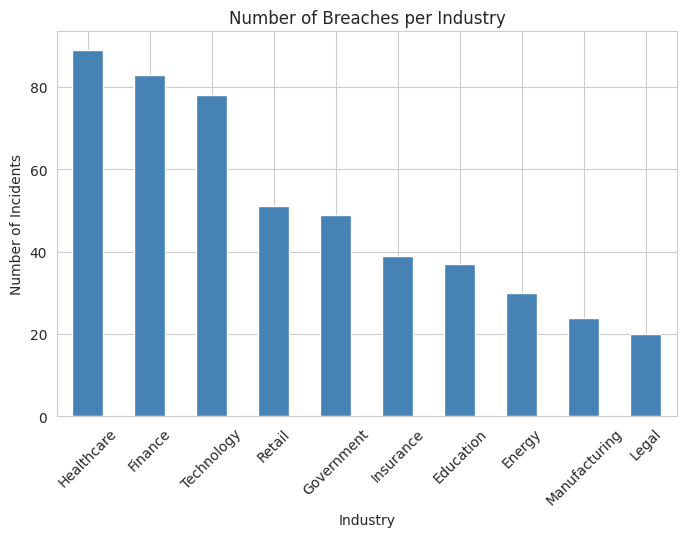

In [6]:
industry_counts = df['industry'].value_counts()
print(industry_counts)

plt.figure(figsize=(8,5))
industry_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Breaches per Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.show()


## Step 6: Most Common Types of Breaches

This step follows the same logic as the previous one, but applied to the `breach_type` column instead — which records *how* each attack was carried out (Phishing, Ransomware, Insider Threat, SQL Injection, etc.). Knowing which attack methods are most common helps organizations prioritize their defenses; for example, if phishing is the top cause, employee training on spotting suspicious emails becomes a high priority.

Here we draw a **horizontal bar chart** instead of a vertical one. This is purely a readability choice — when category names are long, horizontal bars leave more room to display the full label without cutting it off or rotating the text, making the chart easier to scan.


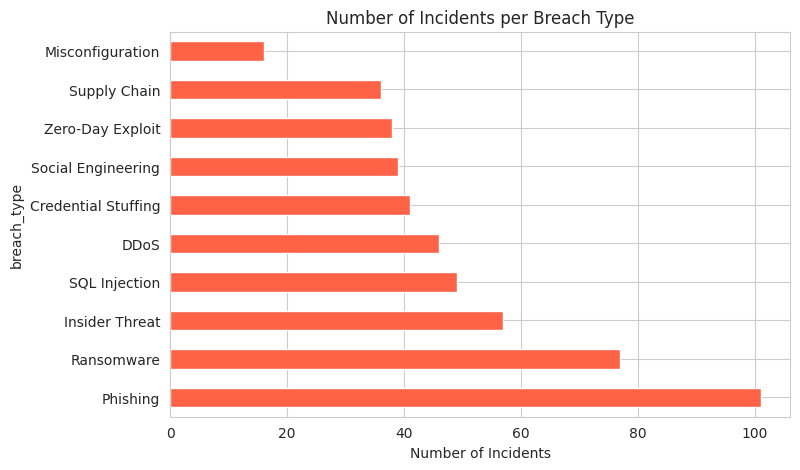

In [7]:
breach_counts = df['breach_type'].value_counts()

plt.figure(figsize=(8,5))
breach_counts.plot(kind='barh', color='tomato')
plt.title('Number of Incidents per Breach Type')
plt.xlabel('Number of Incidents')
plt.show()


## Step 7: How Severe Are the Breaches?

Here we look at the `severity` column, which rates how serious each breach was (Low, Medium, High, Critical). Instead of a bar chart, we use a **pie chart**, which is ideal when we want to show **proportions** — how each category contributes to the whole as a percentage, rather than just raw counts.

`autopct='%1.1f%%'` automatically calculates and displays the percentage each slice represents, so we don't have to compute it manually. Pie charts work best with a small number of categories (here we have 4); with too many slices, they become cluttered and hard to read, which is why bar charts are generally preferred for categories with many unique values.


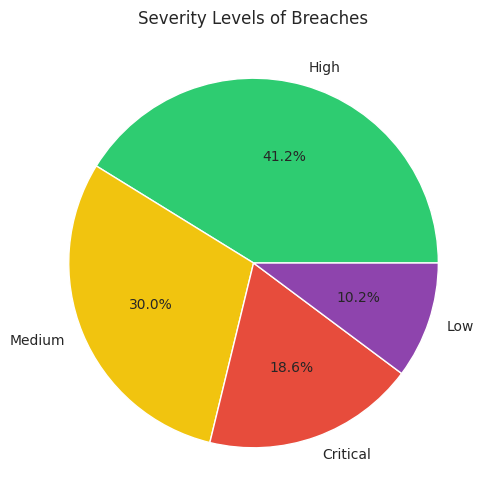

In [8]:
severity_counts = df['severity'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
        colors=['#2ecc71','#f1c40f','#e74c3c','#8e44ad'])
plt.title('Severity Levels of Breaches')
plt.show()


## Step 8: Breaches Over Time

To study trends, we first need proper date values. `pd.to_datetime()` converts the `date` column from plain text (like "2021-05-14") into a real **datetime** object that Python understands, enabling date-based operations like sorting chronologically or extracting the year.

We then count how many incidents occurred each year using `.value_counts()` on the `year` column, and sort the result with `.sort_index()` so years appear in correct order (not by frequency).

This is visualized as a **line chart**, the standard choice for showing how a value changes over time. The connected line makes it easy to spot whether breaches are increasing, decreasing, or staying flat year over year — a pattern that would be much harder to see in a plain table of numbers.


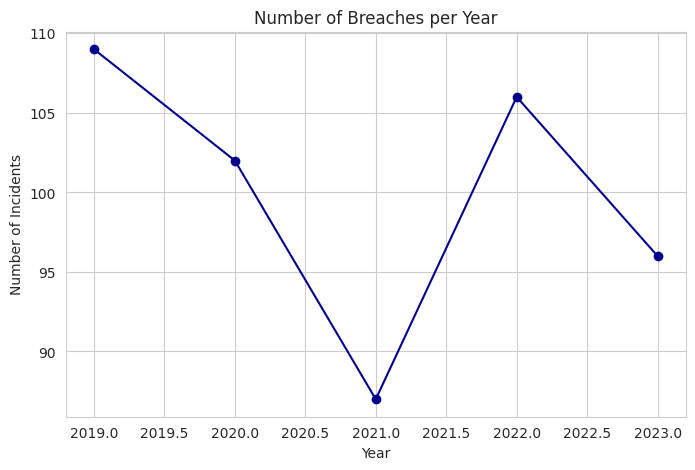

In [9]:
df['date'] = pd.to_datetime(df['date'])

incidents_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(8,5))
incidents_per_year.plot(kind='line', marker='o', color='darkblue')
plt.title('Number of Breaches per Year')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.grid(True)
plt.show()


## Step 9: How Much Money Is Lost?

To understand financial losses, we use a **histogram** — a chart that groups numeric values into ranges called "bins" and shows how many records fall into each range as bars. Unlike a bar chart (which compares categories), a histogram reveals the **distribution shape** of a single numeric column: where most values cluster, and where the extremes lie.

We set `bins=30`, meaning the full range of financial losses is divided into 30 equal-width buckets. We'd expect most breaches to cause relatively small losses, with a smaller number of breaches causing extremely large losses — creating a "right-skewed" shape where the bulk of bars are on the left and a long thin tail stretches to the right.


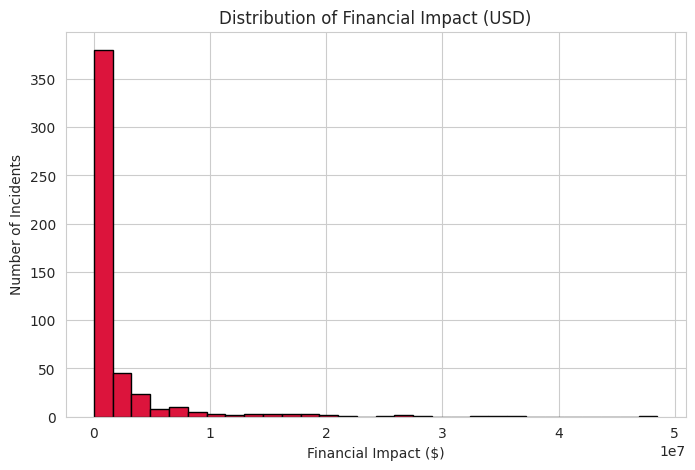

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['financial_impact_usd'], bins=30, color='crimson', edgecolor='black')
plt.title('Distribution of Financial Impact (USD)')
plt.xlabel('Financial Impact ($)')
plt.ylabel('Number of Incidents')
plt.show()


## Step 10: Does Severity Affect Financial Loss?

A **box plot** is a powerful way to compare the spread of a numeric value (financial impact) across multiple categories (severity levels) at once. Each box shows the **middle 50%** of values; the line inside is the median. The "whiskers" extend to typical minimum/maximum values, and individual dots beyond them are **outliers** — unusually extreme cases.

We expect 'Critical' severity incidents to show higher losses than 'Low' severity ones. Because financial losses range from very small to very large numbers, we apply `plt.yscale('log')`, which compresses large values and stretches small ones, making it possible to compare both small and huge losses clearly on the same chart without the small ones disappearing.


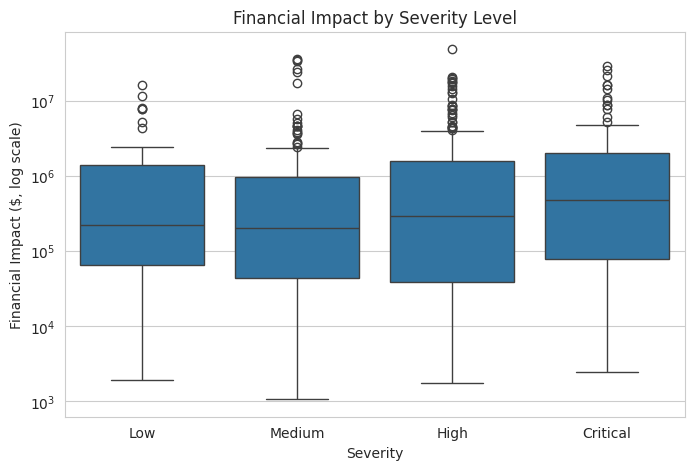

In [11]:
plt.figure(figsize=(8,5))
order = ['Low','Medium','High','Critical']
sns.boxplot(x='severity', y='financial_impact_usd', data=df, order=order)
plt.yscale('log')   # log scale because some losses are MUCH bigger than others
plt.title('Financial Impact by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Financial Impact ($, log scale)')
plt.show()


## Step 11: Does MFA (Multi-Factor Authentication) Help?

**MFA** is a security feature requiring more than just a password to log in (like a code sent to your phone). Here we test whether having MFA enabled actually helps companies detect breaches faster.

`.groupby('mfa_enabled')` splits all rows into two groups: companies with MFA enabled and companies without it. Calling `['detection_time_days'].mean()` then calculates the **average** detection time within each group separately. This grouping technique — split, then summarize — is one of the most powerful and common operations in data analysis, letting us compare any numeric outcome across any categorical grouping.

The resulting bar chart should show whether MFA-enabled companies detect breaches in fewer days on average.


mfa_enabled
No     46.471014
Yes    46.102679
Name: detection_time_days, dtype: float64


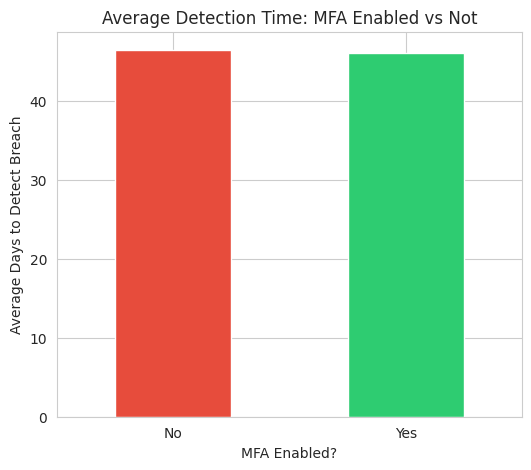

In [12]:
mfa_avg = df.groupby('mfa_enabled')['detection_time_days'].mean()
print(mfa_avg)

plt.figure(figsize=(6,5))
mfa_avg.plot(kind='bar', color=['#e74c3c','#2ecc71'])
plt.title('Average Detection Time: MFA Enabled vs Not')
plt.xlabel('MFA Enabled?')
plt.ylabel('Average Days to Detect Breach')
plt.xticks(rotation=0)
plt.show()


## Step 12: Correlation — Do Numbers Move Together?

**Correlation** is a statistical measure of how strongly two numeric variables relate to each other, expressed as a value between -1 and +1:
- **+1** means as one variable increases, the other reliably increases too
- **-1** means as one increases, the other reliably decreases
- **0** means there's no clear relationship between them

`.corr()` automatically computes this for every pair of numeric columns in our selected list, producing a correlation matrix (a table of correlation values). We then visualize it as a **heatmap**, where colors represent the strength and direction of each relationship — warm colors for positive correlation, cool colors for negative. This makes it instantly visible which variables (like records exposed and financial impact) tend to move together.


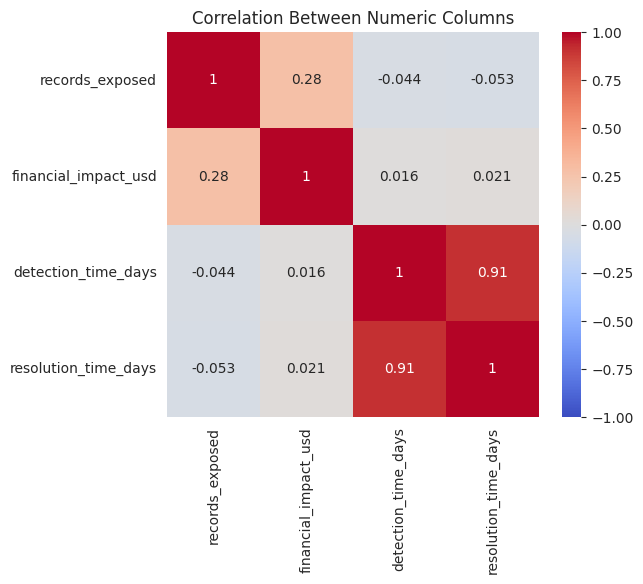

In [13]:
num_cols = ['records_exposed','financial_impact_usd','detection_time_days','resolution_time_days']
correlation = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Numeric Columns')
plt.show()


## Step 13: Final Summary

After all our charts and exploration, it's useful to pull out a handful of concrete numbers that summarize the entire dataset in plain language. This step doesn't introduce any new technique — it simply reuses functions we've already learned (`.value_counts()`, `.idxmax()`, `.mean()`, `.median()`) to answer specific questions directly with printed text instead of charts.

`.idxmax()` is new here: it returns the **label** of the largest value in a Series, rather than the value itself — useful for answering "which category has the highest count?" in one line. This kind of summary is often what gets shared with non-technical stakeholders, since it distills the visual analysis into a few clear, memorable facts.


In [14]:
print('Total incidents:', len(df))
print('Most affected industry:', df['industry'].value_counts().idxmax())
print('Most common breach type:', df['breach_type'].value_counts().idxmax())
print('Average financial loss: ${:,.0f}'.format(df['financial_impact_usd'].mean()))
print('Median detection time:', df['detection_time_days'].median(), 'days')
print('% incidents reported to authorities:',
      round((df['notified_authorities']=='Yes').mean()*100, 1), '%')


Total incidents: 500
Most affected industry: Healthcare
Most common breach type: Phishing
Average financial loss: $2,098,697
Median detection time: 32.0 days
% incidents reported to authorities: 63.8 %


## What We Learned (Conclusion)

1. Some industries (like Finance and Healthcare) get attacked more — likely because they hold valuable personal/financial data that's attractive to hackers.
2. Higher severity breaches cost a lot more money — often 10x or more compared to low-severity incidents, showing that severity ratings are meaningful, not arbitrary labels.
3. Companies using MFA tend to detect breaches faster, suggesting that basic security hygiene measurably improves real-world outcomes.
4. Financial losses are **skewed** — most breaches cost relatively little, but a small number of huge breaches pull the average upward significantly, which is why median is often a more trustworthy summary than mean for cost data.

This is the heart of EDA: using simple stats and charts to uncover real patterns *before* building any predictive model — letting the data guide our next questions.
